In [6]:
# Set default parameters for publication quality plots
import matplotlib.pyplot as plt

SMALL_SIZE = 14
MEDIUM_SIZE = 16
BIGGER_SIZE = 18

plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)  # fontsize of the figure title
plt.rc("lines", linewidth=3)

In [25]:
import idaes
import pandas as pd
import pyomo.environ as pyo
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
###OPTIMIZATION MODEL, see written model in report, assisted by class pyomo notes
#please Note this can take up to 10 minutes to run depending on inputs


##Get Month data from excel sheet
df = pd.read_excel('SmartHomeSeptember.xlsx')
demand_array = df["Demand (kWh)"].values
solar_array = df["Solar gen (kWh)"].values

# monthly time steps
T = len(demand_array)

# Length of experimental run
num_years = 1
total_months = num_years * 12

##Defining grid costs from South bend grid reference
# On-peak is from 2:00 PM (14) to 8:00 PM (20); off-peak otherwise.
grid_cost = [0.2537 if 14 <= ((t // 60) % 24) < 20 else 0.0825 for t in range(T)]


##Equipment Parameters to be used for constratins
battery_cost = 15000       # [$ per battery]
solar_cost   = 1300        # [estimate $ per solar panel]  
battery_capacity = 13.5    # kWh per battery
max_batteries = 10         # maximum batteries installable
max_solar_panels = 50      # maximum solar panels installable
min_soc_frac = 0.2         # minimum state-of-charge fraction (20%), this is to promote battery help


# Maximum cost by using grid only ($857 per year)
base_monthly_cost = sum(grid_cost[t] * demand_array[t] for t in range(T))
base_total_cost = base_monthly_cost * total_months

#### CREATE THE MODEL
def create_model():
    model = pyo.ConcreteModel()
    
    model.T = pyo.RangeSet(0, T-1)
    
    # demand comes directly from the excel
    model.demand = pyo.Param(model.T, 
                             initialize={t: float(demand_array[t]) for t in range(T)},
                             within=pyo.NonNegativeReals)
    
    # solar generation also from excel
    model.solar_meas = pyo.Param(model.T, 
                                 initialize={t: float(solar_array[t]) for t in range(T)},
                                 within=pyo.NonNegativeReals)
    
    # grid cost comes from work above
    model.grid_cost = pyo.Param(model.T, 
                                initialize={t: grid_cost[t] for t in range(T)},
                                within=pyo.NonNegativeReals)
    
    # budget is something we define
    model.budget = pyo.Param(initialize=100000, mutable=True)
    
    # Decision Variables:
    model.batteries = pyo.Var(within=pyo.NonNegativeIntegers, bounds=(0, max_batteries)) #both of these two we wanted to be integer values
    model.solar = pyo.Var(within=pyo.NonNegativeIntegers, bounds=(0, max_solar_panels))
    
    # Operational variables, define to meet demand/energy balance
    model.charge = pyo.Var(model.T, within=pyo.NonNegativeReals)
    model.discharge = pyo.Var(model.T, within=pyo.NonNegativeReals)
    model.soc = pyo.Var(model.T, within=pyo.NonNegativeReals)
    model.grid_import = pyo.Var(model.T, within=pyo.NonNegativeReals)
    
    # Objective: maximize savings = baseline total cost minus actual grid cost that we used
    def savings_rule(m):
        actual_cost_month = sum(m.grid_cost[t] * m.grid_import[t] for t in m.T)
        return base_total_cost - (actual_cost_month * total_months)
    model.savings = pyo.Objective(rule=savings_rule, sense=pyo.maximize)

    ###CONSTRAINTS
    # Budget Constraint
    def capital_budget_rule(m):
        return battery_cost * m.batteries + solar_cost * m.solar <= m.budget
    model.capital_budget = pyo.Constraint(rule=capital_budget_rule)
    

    # 1. Start SOC at the 20% lower limit
    def initial_soc_rule(m):
        return m.soc[0] == min_soc_frac * m.batteries * battery_capacity
    model.initial_soc = pyo.Constraint(rule=initial_soc_rule)
    
    # SOC mdoel for battery
    def soc_update_rule(m, t):
        if t < T - 1:
            return m.soc[t+1] == m.soc[t] + (0.93 * m.charge[t] - (1/0.93) * m.discharge[t]) #this is our model with dt=1 minute
        return pyo.Constraint.Skip
    model.soc_update = pyo.Constraint(model.T, rule=soc_update_rule)
    
    # cant exceed battery(s) capacity
    def soc_limit_rule(m, t):
        return m.soc[t] <= m.batteries * battery_capacity
    model.soc_limit = pyo.Constraint(model.T, rule=soc_limit_rule)
    
    # dont go below 20% SOC to maintain battery health
    def soc_minimum_rule(m, t):
        return m.soc[t] >= min_soc_frac * m.batteries * battery_capacity
    model.soc_minimum = pyo.Constraint(model.T, rule=soc_minimum_rule)
    
    # total energy balance must be met, extra energy used to charge battery
    def energy_balance_rule(m, t):
        return m.solar * m.solar_meas[t] + m.discharge[t] + m.grid_import[t] >= m.demand[t] + m.charge[t]
    model.energy_balance = pyo.Constraint(model.T, rule=energy_balance_rule)
    
    # battery cant discharge more than it has
    def discharge_limit_rule(m, t):
        return m.discharge[t] <= m.soc[t]
    model.discharge_limit = pyo.Constraint(model.T, rule=discharge_limit_rule)
    
    # charge cant exceed capacity
    def charge_limit_rule(m, t):
        return m.charge[t] <= m.batteries * battery_capacity - m.soc[t]
    model.charge_limit = pyo.Constraint(model.T, rule=charge_limit_rule)
    

    #discharge allowed time constraint based on previous analysis
    allowed_discharge_times = [t for t in range(T)
                               if 3.5 <= ((t // 60) % 24) < 21]

    def discharge_time_rule(m, t):
        if t not in allowed_discharge_times:
            return m.discharge[t] == 0
        return pyo.Constraint.Skip

    model.discharge_time = pyo.Constraint(model.T, rule=discharge_time_rule)

    
    # time‐step in hours
    dt = 1/60.0  
    
    # per‐battery max power see powerwall 2 reference
    max_charge_power_per_batt = 5.0    
    max_discharge_power_per_batt = 7.0 
    
    # Limit how fast we can charge and discharge the batter
    def charge_rate_limit(m, t):
        return m.charge[t] <= max_charge_power_per_batt * m.batteries * dt
    model.charge_rate_limit = pyo.Constraint(model.T, rule=charge_rate_limit)

    def discharge_rate_limit(m, t):
        return m.discharge[t] <= max_discharge_power_per_batt * m.batteries * dt
    model.discharge_rate_limit = pyo.Constraint(model.T, rule=discharge_rate_limit)
    
    return model

###SOLVE the model, example of budget = $20000
solver = pyo.SolverFactory('cbc')
model = create_model()
model.budget.value = 20000 
result = solver.solve(model, tee=True)

opt_batteries = round(pyo.value(model.batteries))
opt_solar = round(pyo.value(model.solar))
actual_cost_month = sum(pyo.value(model.grid_cost[t]) * pyo.value(model.grid_import[t]) for t in range(T))
actual_cost_total = actual_cost_month * total_months
savings = base_total_cost - actual_cost_total

print(f"Optimal Batteries: {opt_batteries}")
print(f"Optimal Solar Panels: {opt_solar}")
print(f"Total Operating Cost over period ({num_years} years): ${actual_cost_total:,.2f}")
print(f"Total Savings (vs. grid-only): ${savings:,.2f}")



Welcome to the CBC MILP Solver 
Version: 2.10.10 
Build Date: Jun  7 2023 

command line - /Users/joeblum/.idaes/bin/cbc -printingOptions all -import /var/folders/y1/wd6r95t910q2vqlzx0vs92zw0000gn/T/tmppc2zdi1j.pyomo.lp -stat=1 -solve -solu /var/folders/y1/wd6r95t910q2vqlzx0vs92zw0000gn/T/tmppc2zdi1j.pyomo.soln (default strategy 1)
Option for printingOptions changed from normal to all
 CoinLpIO::readLp(): Maximization problem reformulated as minimization
Coin0009I Switching back to maximization to get correct duals etc
Presolve 314089 (-44103) rows, 153897 (-18902) columns and 837859 (-81911) elements
Statistics for presolved model
Original problem has 2 integers (0 of which binary)
Presolved problem has 2 integers (0 of which binary)
==== 110698 zero objective 3 different
10800 variables have objective of -3.0444
32399 variables have objective of -0.99
110698 variables have objective of -0
==== absolute objective values 3 different
110698 variables have objective of 0
32399 variables 

In [2]:
## Need to run optimiation over different budgets and durations. Then save data

# Tax credit see IRS reference
tax_credit = 0.30

# cap costs
battery_cost = 15000       # $ per battery
solar_cost   = 1300        # estimate $ per solar panel

# Net capital costs after tax credit
net_battery_cost = battery_cost * (1 - tax_credit)
net_solar_cost   = solar_cost   * (1 - tax_credit)

# Define the budgets and analysis durations (years)
budgets = [20000, 30000, 40000]
durations = [1, 3, 5]

# Container for results
results = []

# Loop over each budget and duration
for budget in budgets:
    for years in durations:
        # Recalculate total months and base total cost for this duration
        total_months = years * 12
        base_total_cost = base_monthly_cost * total_months
        
        # Create and solve the model
        model = create_model()
        model.budget = budget
        solver = pyo.SolverFactory('cbc')
        solver.solve(model, tee=False)
        
        # Extract results
        savings = pyo.value(model.savings)
        n_batt = pyo.value(model.batteries)
        n_solar = pyo.value(model.solar)
        cap_cost = battery_cost * n_batt + solar_cost * n_solar
        
        # Store in list
        results.append({
            'budget': budget,
            'years': years,
            'savings': savings,
            'cap_cost': cap_cost
        })

# Convert to DataFrame for easy plotting
results_df = pd.DataFrame(results)

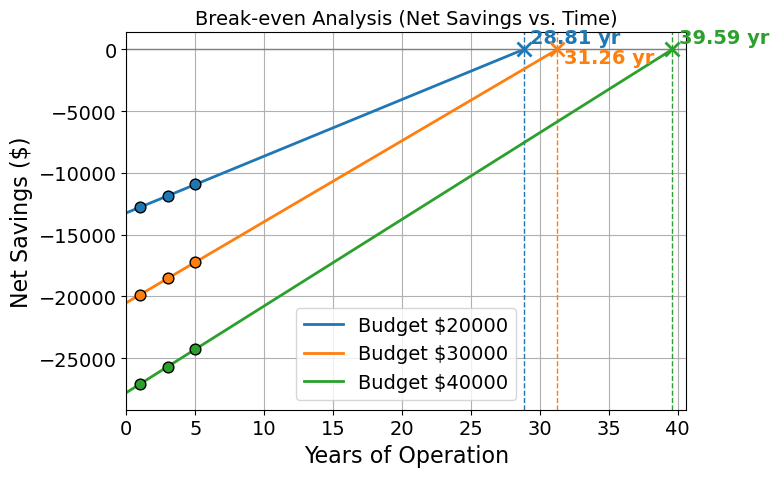

In [23]:

#NOW PRINT THE SAVINGS ANALYSIS BASED ON THESE RESULTS, used GPT some here to make it cleaner
tax_credit = 0.30
results_df['net_cap_cost'] = results_df['cap_cost'] * (1 - tax_credit)

# Define budgets, colors, and annotation offsets
budgets    = sorted(results_df['budget'].unique())
colors     = {20000: 'C0', 30000: 'C1', 40000: 'C2'}
ann_shift  = {20000: (5,  5), 30000: (5, -10), 40000: (5,  5)}

fig, ax = plt.subplots(figsize=(8,5))

# Plot each budget
for b in budgets:
    df_b    = results_df[results_df['budget']==b].sort_values('years')
    yrs     = df_b['years'].values
    sav     = df_b['savings'].values
    net_cap = df_b['net_cap_cost'].iloc[0]
    c       = colors[b]
    dx, dy  = ann_shift[b]

    # slope 
    m = (yrs@sav) / (yrs**2).sum()
    t_be = net_cap / m

    # plot break-even line
    x_line = np.linspace(0, t_be, 100)
    y_line = m*x_line - net_cap
    ax.plot(x_line, y_line, color=c, lw=2, label=f'Budget ${b}')

    # plot data points
    pts = sav - net_cap
    ax.scatter(yrs, pts, color=c, edgecolor='k', s=60, zorder=5)

    # mark the break-even point
    ax.plot(t_be, 0, 'x', color=c, markersize=10, mew=2, zorder=6)

    # vertical line at break-even
    ax.axvline(t_be, color=c, linestyle='--', lw=1)

    # annotate the year
    ax.annotate(f'{t_be:.2f} yr', xy=(t_be,0), xytext=(dx,dy),
                textcoords='offset points', color=c, fontweight='bold')

# horizontal zero line
ax.axhline(0, color='gray', linestyle='-', lw=1)

# x‐ticks at every integer year (and extend to max break-even)
all_be = [ (results_df.loc[results_df.budget==b,'cap_cost'].iloc[0]*(1-tax_credit)) /
           ((results_df.loc[results_df.budget==b,'years']@results_df.loc[results_df.budget==b,'savings']) /
            (results_df.loc[results_df.budget==b,'years']**2).sum())
           for b in budgets ]
max_x = max(max(results_df['years']), max(all_be))
ax.set_xticks(np.arange(0, np.ceil(max_x)+5, 5))
ax.set_xlim(0, max_x+1)

ax.set_xlabel('Years of Operation')
ax.set_ylabel('Net Savings ($)')
ax.set_title('Break-even Analysis (Net Savings vs. Time)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


In [24]:
#checking savings/slopes
#budgets you swept over
budgets = sorted(results_df['budget'].unique())

slopes = []
for b in budgets:
    dfb    = results_df[results_df['budget']==b].sort_values('years')
    years  = dfb['years'].values
    sav    = dfb['savings'].values
    # slope through origin: m = Σ(years*sav) / Σ(years^2)
    m      = np.sum(years * sav) / np.sum(years**2)
    slopes.append({'Budget ($)': b, 'Slope ($/yr)': m})

slopes_df = pd.DataFrame(slopes)
print(slopes_df.to_string(index=False))

 Budget ($)  Slope ($/yr)
      20000    459.191475
      30000    656.182898
      40000    701.874076


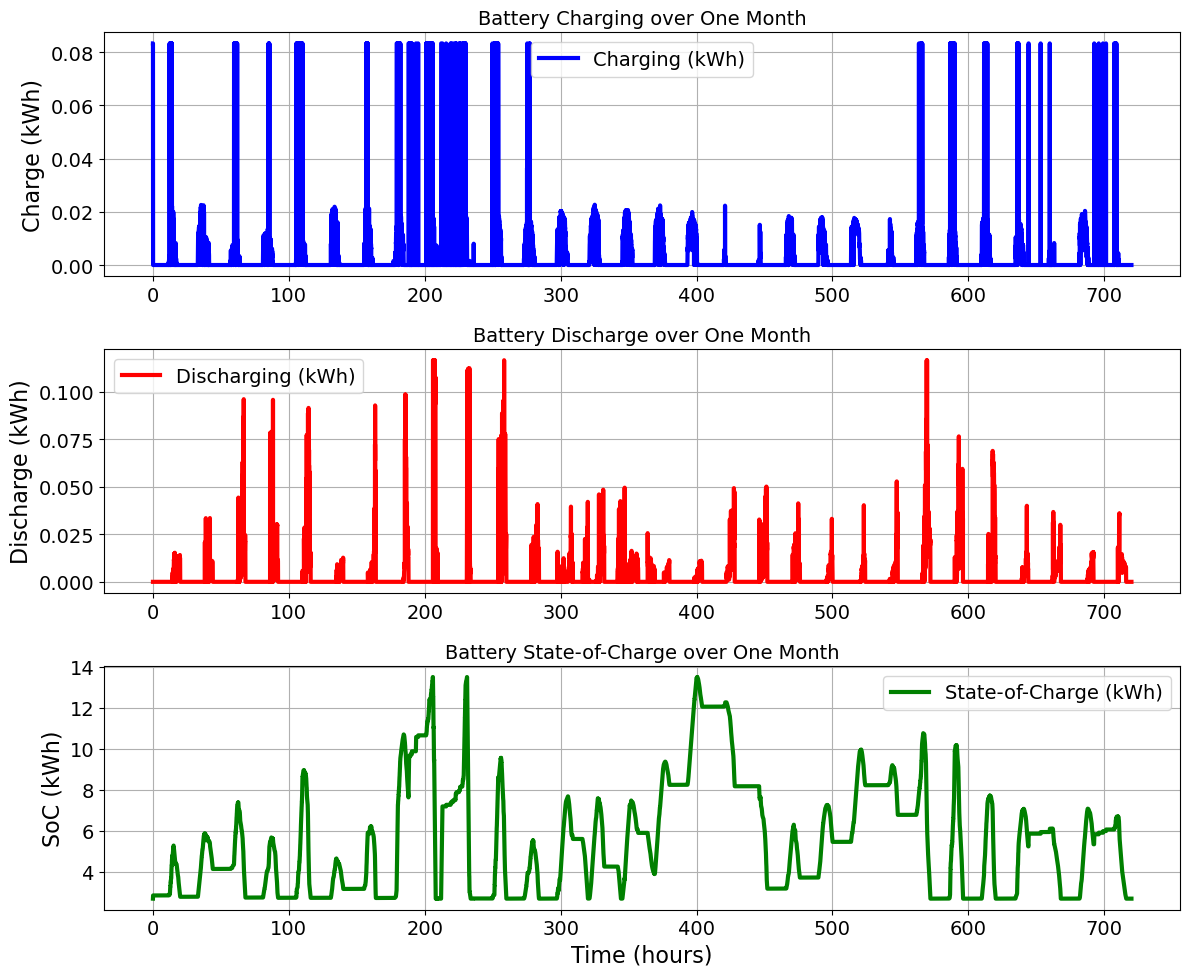

In [27]:
#wanted to print SOC and charge/discharge to make sure it looked reasonable
    #this is how i realized we needed to include discharge/charge rate limits to prevent any unreasoable kWh spikes

# Define the number of minutes in 30 days
month_length = 30 * 1440  
# Don’t exceed the total horizon T
month_length = min(month_length, T)

# Create an index for the month
month_indices = range(month_length)

# Extract model values for month
charge_month   = [pyo.value(model.charge[t])    for t in month_indices]
discharge_month= [pyo.value(model.discharge[t]) for t in month_indices]
soc_month      = [pyo.value(model.soc[t])       for t in month_indices]

# Convert minute‐indices to hours for the x‐axis
time_hours = [t/60 for t in month_indices]

# Plot charging, discharging, and SoC over one month
plt.figure(figsize=(12, 10))

# Charging subplot
plt.subplot(3,1,1)
plt.plot(time_hours, charge_month,    color='blue',  label='Charging (kWh)')
plt.ylabel("Charge (kWh)")
plt.title("Battery Charging over One Month")
plt.legend()
plt.grid(True)

# Discharging subplot
plt.subplot(3,1,2)
plt.plot(time_hours, discharge_month, color='red',   label='Discharging (kWh)')
plt.ylabel("Discharge (kWh)")
plt.title("Battery Discharge over One Month")
plt.legend()
plt.grid(True)

# State‐of‐Charge subplot
plt.subplot(3,1,3)
plt.plot(time_hours, soc_month,       color='green', label='State-of-Charge (kWh)')
plt.xlabel("Time (hours)")
plt.ylabel("SoC (kWh)")
plt.title("Battery State-of-Charge over One Month")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
